# Income Classification: End-to-End Machine Learning Project

This notebook performs an end-to-end analysis and classification of income levels using the income_evaluation.csv dataset. We will cover data loading, EDA, preprocessing, modeling, and evaluation.

## 1. Load the Dataset

Download the dataset from the Kaggle link (https://www.kaggle.com/datasets/lodetomasi1995/income-classification/data) and load it into the Python environment using pandas.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('income_evaluation.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset loaded successfully!
Shape: (32561, 15)
   age          workclass   fnlwgt   education   education-num  \
0   39          State-gov    77516   Bachelors              13   
1   50   Self-emp-not-inc    83311   Bachelors              13   
2   38            Private   215646     HS-grad               9   
3   53            Private   234721        11th               7   
4   28            Private   338409   Bachelors              13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

    capital-gain   capital-loss   hours-per-week  native-country  income  
0    

## 2. Exploratory Data Analysis (EDA) and Visualizations

Perform EDA including summary statistics, data types, missing values, and create visualizations such as histograms, bar plots, and correlation heatmaps using libraries like matplotlib and seaborn.

Data Types:
age                 int64
 workclass         object
 fnlwgt             int64
 education         object
 education-num      int64
 marital-status    object
 occupation        object
 relationship      object
 race              object
 sex               object
 capital-gain       int64
 capital-loss       int64
 hours-per-week     int64
 native-country    object
 income            object
dtype: object

Summary Statistics:
                 age  workclass        fnlwgt  education   education-num  \
count   32561.000000      32561  3.256100e+04      32561    32561.000000   
unique           NaN          9           NaN         16             NaN   
top              NaN    Private           NaN    HS-grad             NaN   
freq             NaN      22696           NaN      10501             NaN   
mean       38.581647        NaN  1.897784e+05        NaN       10.080679   
std        13.640433        NaN  1.055500e+05        NaN        2.572720   
min        17.000000        NaN

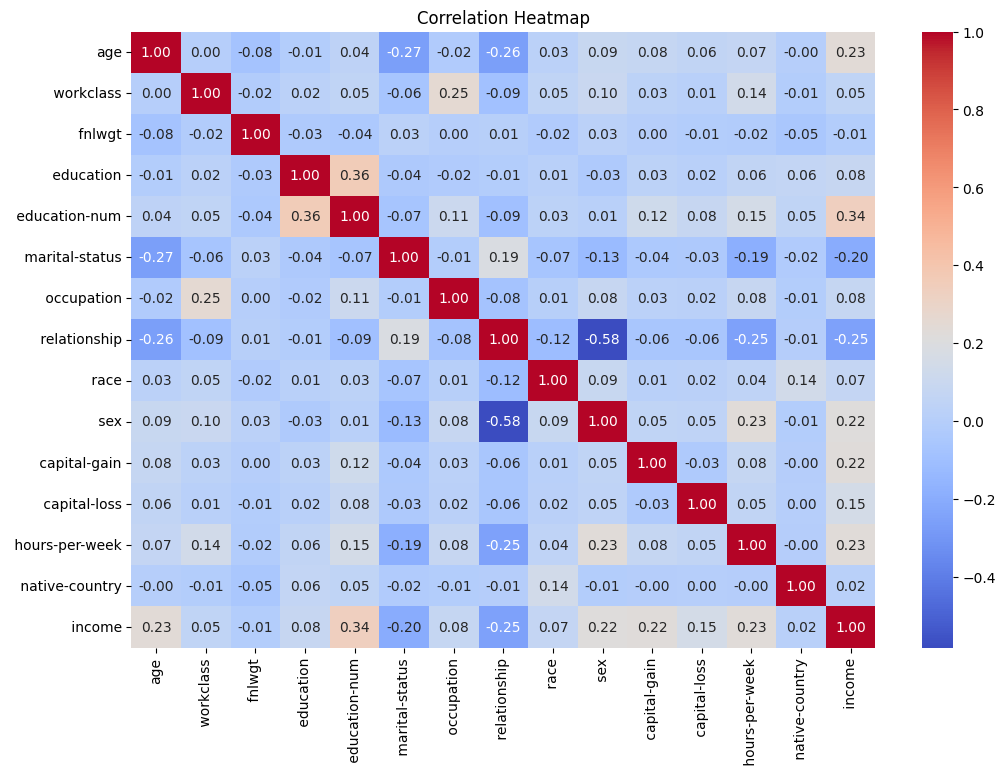

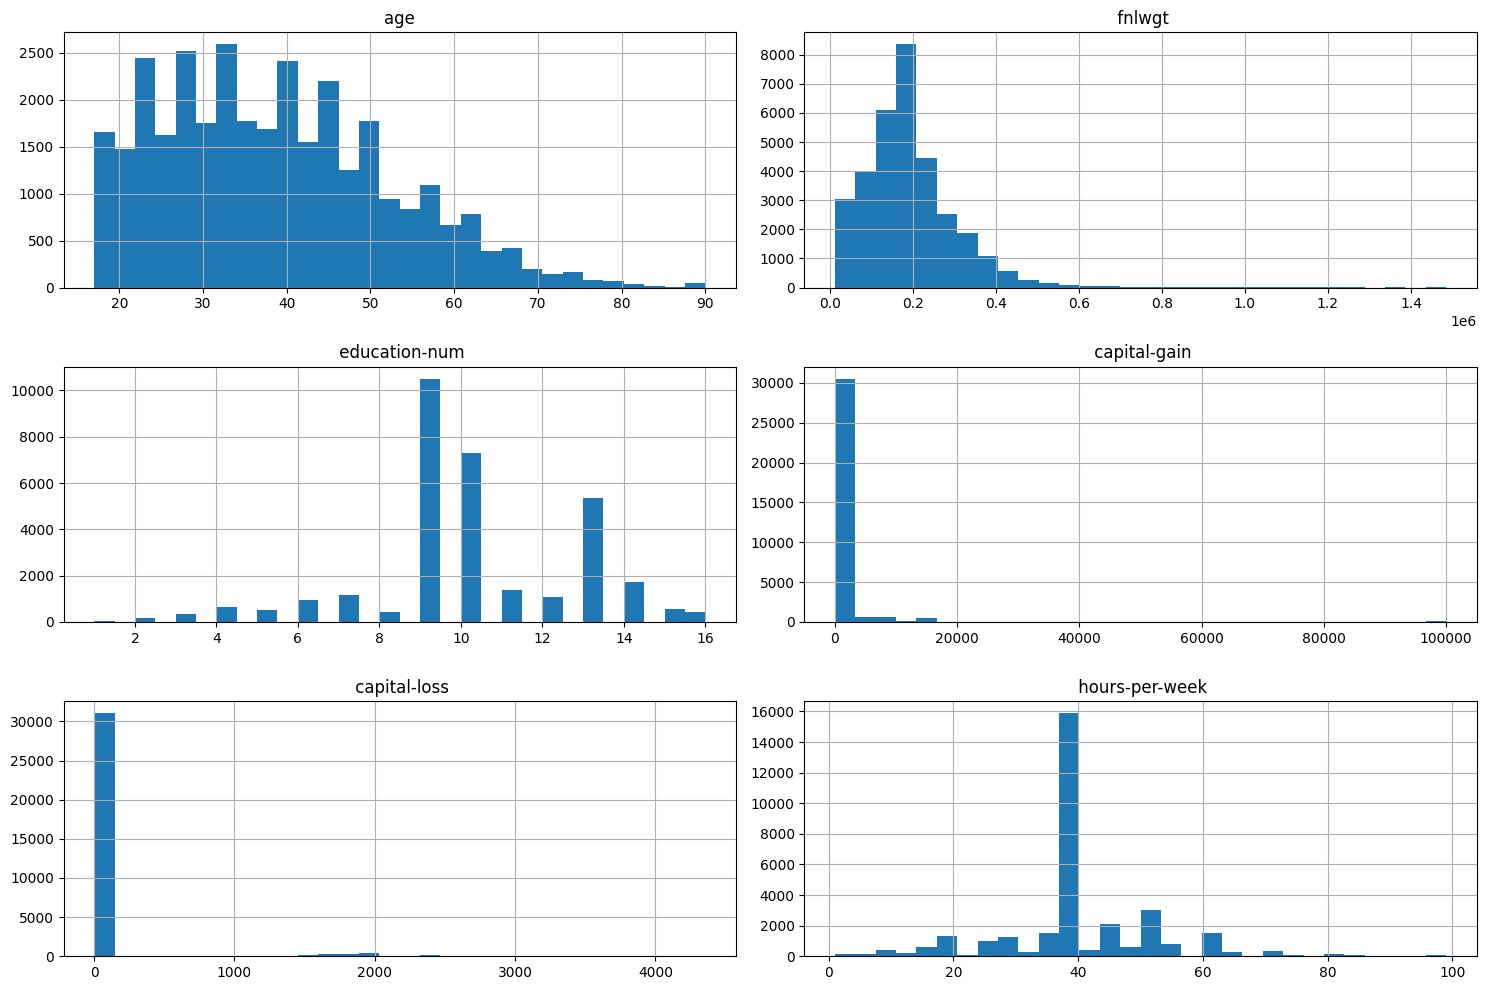

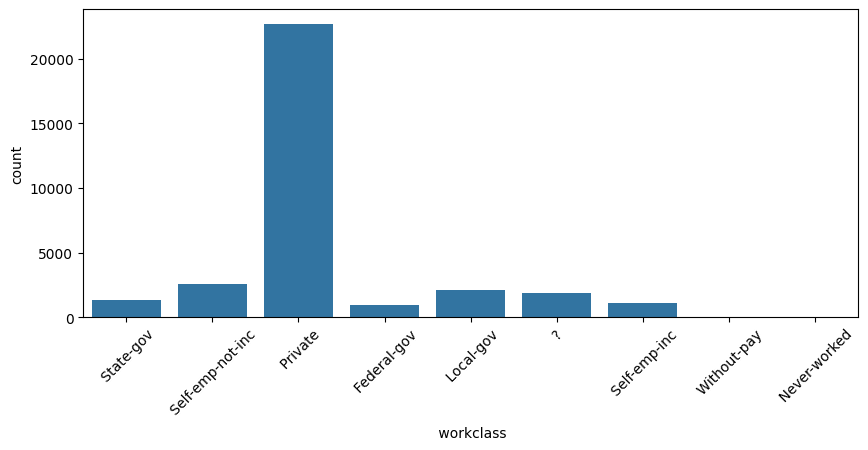

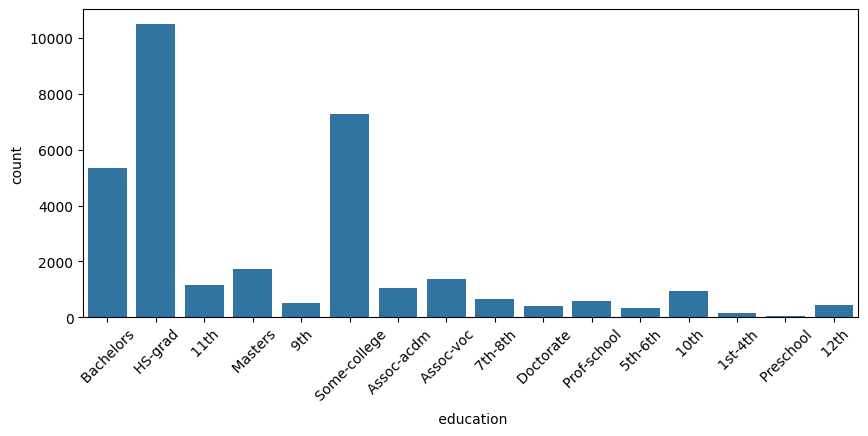

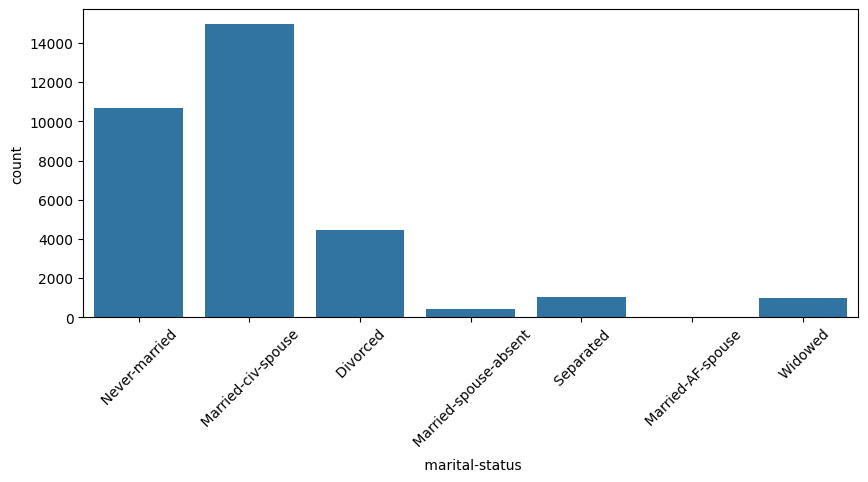

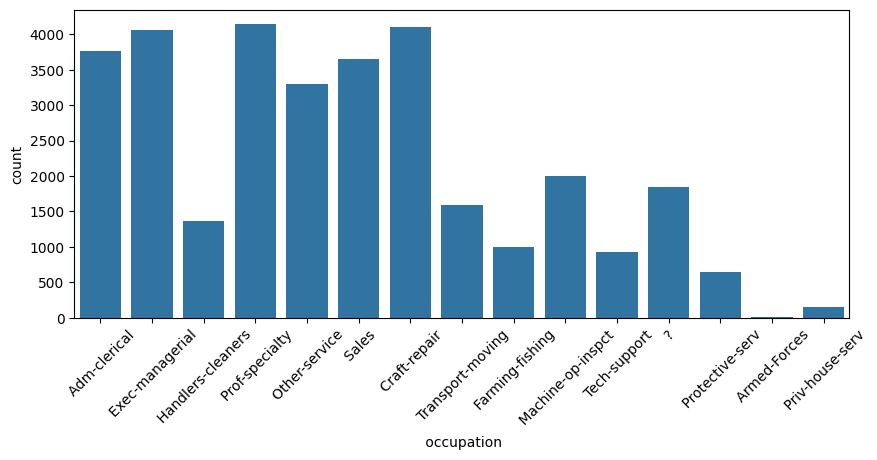

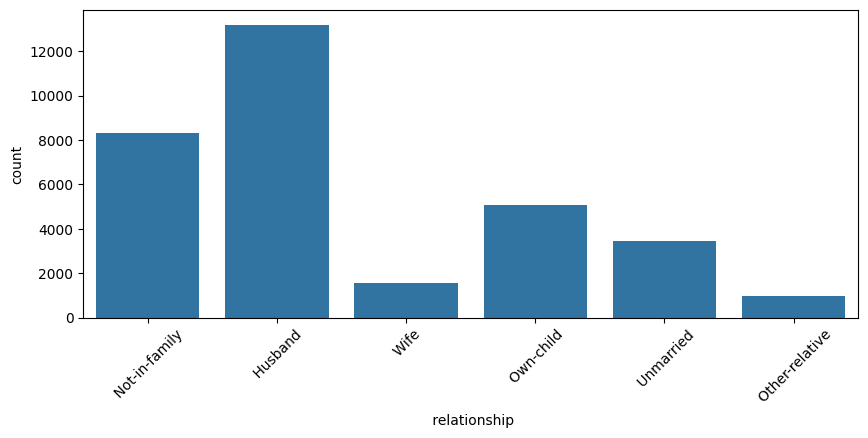

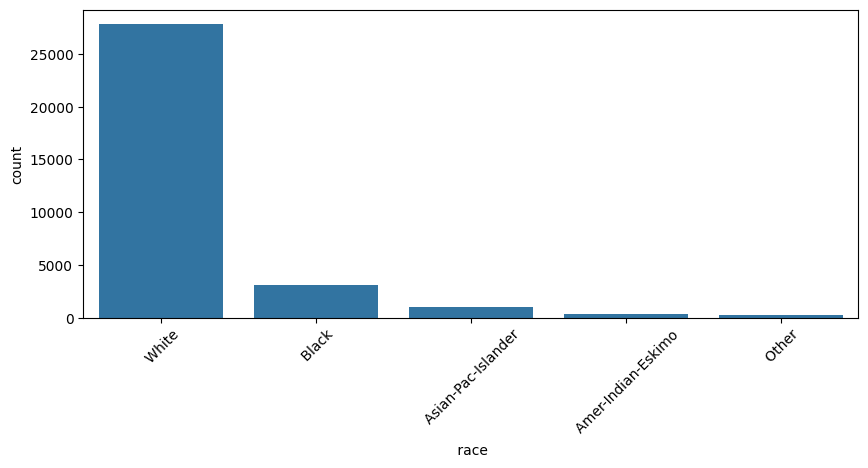

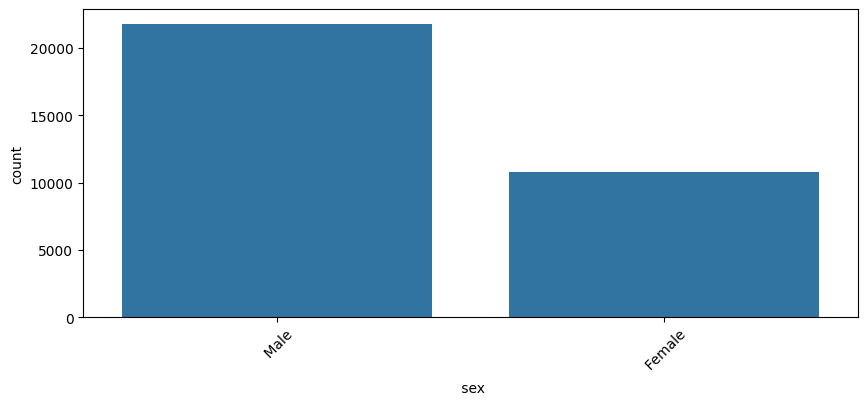

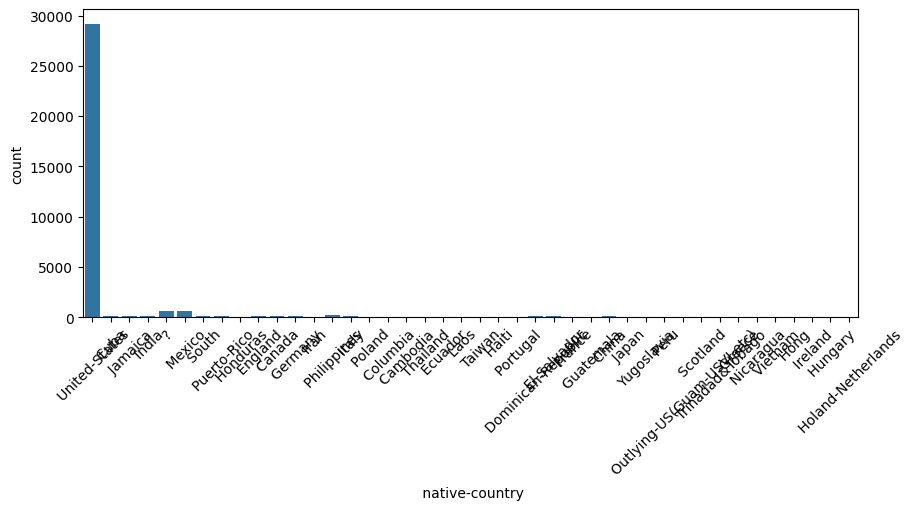

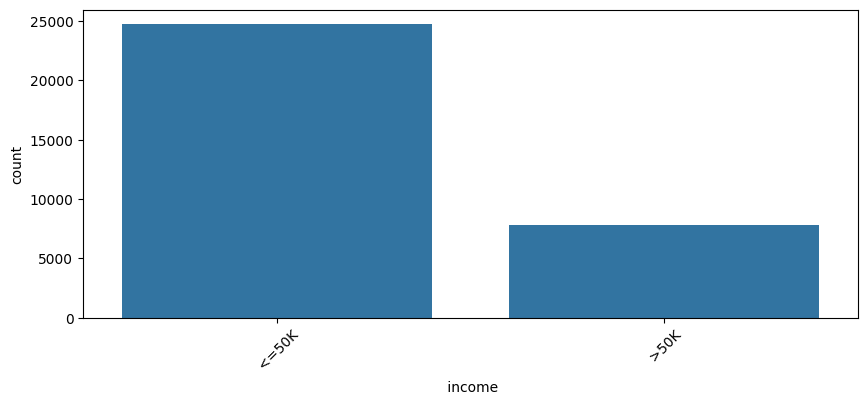

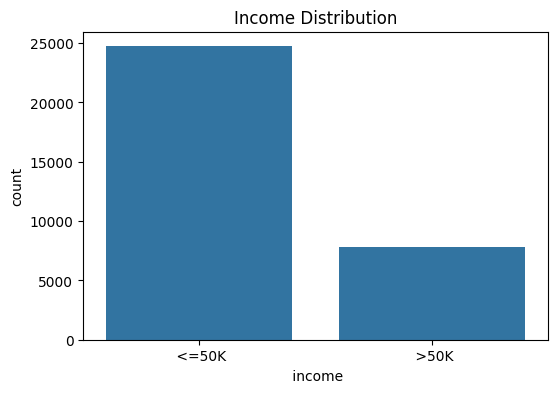

In [2]:
# Basic info
print("Data Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Encode categorical variables for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df[col])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Histograms for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# Bar plots for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=' income', data=df)
plt.title('Income Distribution')
plt.show()

## 3. Check Distributions and Skewness, Apply Transformations

Analyze distributions and skewness of numerical variables using statistical tests and plots, then apply transformations like log or Box-Cox if needed to normalize data.

Skewness of numerical features:
age                 0.558718
 fnlwgt             1.446913
 education-num     -0.311662
 capital-gain      11.953297
 capital-loss       4.594417
 hours-per-week     0.227632
dtype: float64


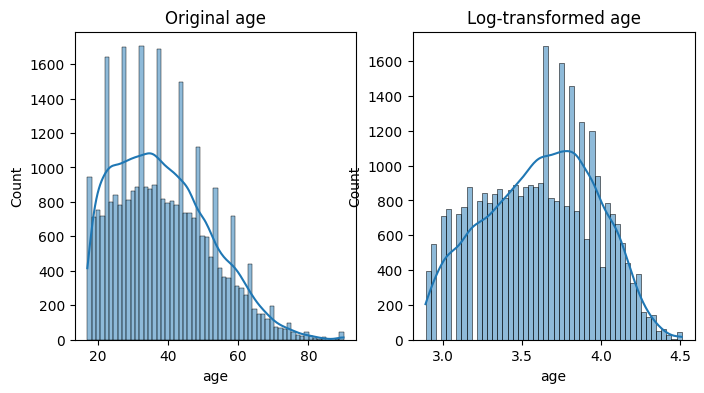

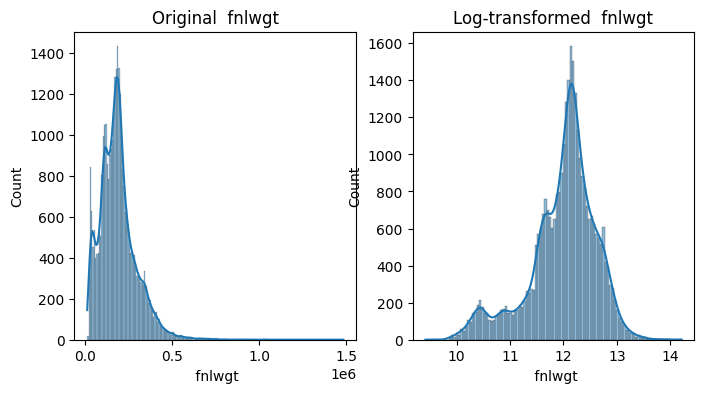

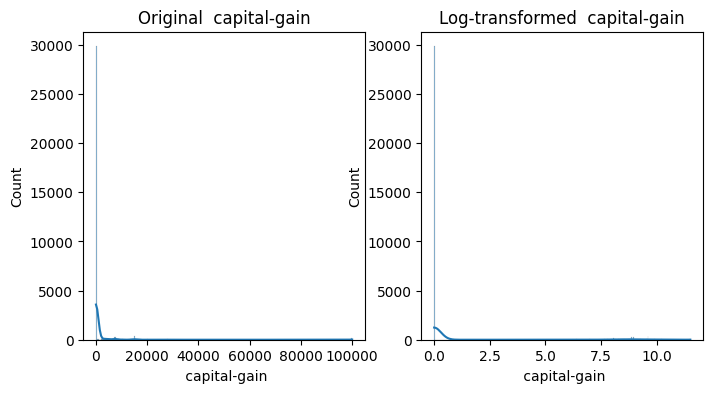

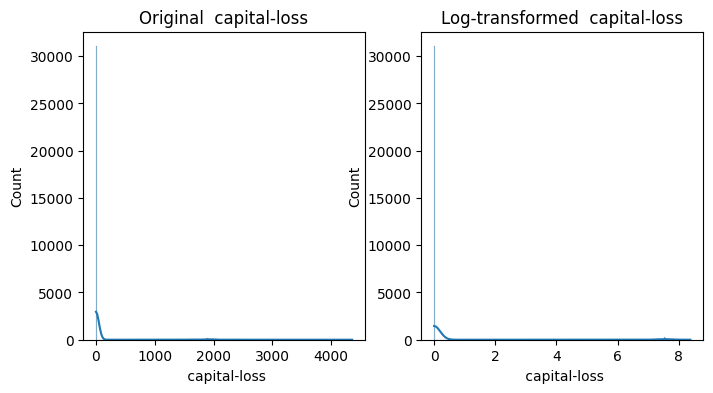

Transformations applied to skewed features.


In [3]:
# Check skewness
from scipy.stats import skew

skewness = df[numerical_cols].apply(lambda x: skew(x.dropna()))
print("Skewness of numerical features:")
print(skewness)

# Plot distributions for skewed features
skewed_features = skewness[abs(skewness) > 0.5].index
for col in skewed_features:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log-transformed {col}')
    plt.show()

# Apply log transformation to highly skewed features
df_transformed = df.copy()
for col in skewed_features:
    if (df[col] > 0).all():  # Ensure positive values
        df_transformed[col] = np.log1p(df[col])

print("Transformations applied to skewed features.")

## 4. Check and Treat Outliers, Apply Feature Scaling

Detect outliers using methods like IQR or Z-score, treat them by removal or capping, and apply feature scaling techniques such as standardization or normalization using scikit-learn. Also, encode categorical variables.

In [4]:
# Handle missing values (if any)
df_clean = df_transformed.fillna(df_transformed.median(numeric_only=True))

# Encode categorical variables
df_encoded = df_clean.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Detect outliers using IQR for numerical features
outliers = {}
for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = ((df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)).sum()

print("Number of outliers per feature:")
print(outliers)

# Cap outliers
for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_encoded[col] = np.clip(df_encoded[col], lower_bound, upper_bound)

print("Outliers treated by capping.")

# Feature scaling
scaler = StandardScaler()
features = [col for col in df_encoded.columns if col != ' income']
df_scaled = df_encoded.copy()
df_scaled[features] = scaler.fit_transform(df_encoded[features])

print("Feature scaling applied.")

Number of outliers per feature:
{'age': np.int64(0), ' fnlwgt': np.int64(1823), ' education-num': np.int64(1198), ' capital-gain': np.int64(2712), ' capital-loss': np.int64(1519), ' hours-per-week': np.int64(9008)}
Outliers treated by capping.
Feature scaling applied.


## 5. Create a Machine Learning Model for Classification

Build a baseline ML model (e.g., Logistic Regression) to classify income levels, including data splitting, training, and initial evaluation using metrics like accuracy and classification report.

In [5]:
# Prepare data for modeling
X = df_scaled[features]
y = df_scaled[' income']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Baseline Model: Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Baseline Model: Logistic Regression
Accuracy: 0.8086903116843237
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      4945
           1       0.67      0.41      0.51      1568

    accuracy                           0.81      6513
   macro avg       0.75      0.67      0.70      6513
weighted avg       0.79      0.81      0.79      6513



## 6. Check and Treat Overfitting

Evaluate the model for overfitting using cross-validation, train-test performance gaps, and apply regularization techniques if necessary.

In [6]:
# Check for overfitting
train_acc = lr.score(X_train, y_train)
test_acc = lr.score(X_test, y_test)
print(f"Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")

# Cross-validation
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean()}")

# If overfitting, apply regularization (L2 by default in LogisticRegression)

Train Accuracy: 0.8077395577395577, Test Accuracy: 0.8086903116843237
Cross-validation Accuracy scores: [0.80500537 0.8046683  0.8088145  0.80912162 0.80942875]
Mean CV Accuracy: 0.8074077086801636


## 7. Compare Supervised ML Algorithms

Implement and compare multiple supervised algorithms including Decision Trees, Random Forest, SVM, and XGBoost, using cross-validation and metrics to select the best model.

In [7]:
# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'CV_Accuracy': cv_acc}

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

# Best model
best_model = results_df['Accuracy'].idxmax()
print(f"\nBest Model: {best_model} with Accuracy: {results_df.loc[best_model, 'Accuracy']}")

               Accuracy  CV_Accuracy
Decision Tree  0.767695     0.775560
Random Forest  0.827729     0.827278
SVM            0.830646     0.828261
XGBoost        0.842469     0.835017

Best Model: XGBoost with Accuracy: 0.8424689083371718
